# How this notebook is laid out - Decision Tree for Warehouse hazard Prediction

1) First load required packages (including pandas and scikitlearn)
2) Generate Dataset (run once)
3) Train a Decision Tree Classifier
4) Plot Training vs Cross-Validation Accuracy
5) Answers to questions in tasks 1, 2, and 5 are provided inline within the cells below


In [9]:
# Verify required packages are available
import sys
print(f"Python version: {sys.version}")

try:
    import numpy as np
    print(f"✓ numpy {np.__version__} is available")
except ImportError as e:
    print(f"✗ numpy not available: {e}")

try:
    import pandas as pd
    print(f"✓ pandas {pd.__version__} is available")
except ImportError as e:
    print(f"✗ pandas not available: {e}")

try:
    import matplotlib.pyplot as plt
    print("✓ matplotlib is available")
except ImportError as e:
    print(f"✗ matplotlib not available: {e}")

try:
    import sklearn
    print(f"✓ scikit-learn {sklearn.__version__} is available")
except ImportError as e:
    print(f"✗ scikit-learn not available: {e}")
    print("Installing scikit-learn...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--break-system-packages", "scikit-learn"])

print("All required packages are ready!")

Python version: 3.12.13 (main, Mar  3 2026, 12:39:30) [Clang 17.0.0 (clang-1700.6.3.2)]
✓ numpy 2.4.1 is available
✓ pandas 3.0.1 is available
✓ matplotlib is available
✓ scikit-learn 1.8.0 is available
All required packages are ready!


# Generate dataset (Run once)

Dataset: Generate warehouse_hazard.csv from the code below. The features are:

| Feature            | Description                                 | Range    |
|--------------------|---------------------------------------------|----------|
| `load_kg`          | Weight stored at the location (kg)          | 100–1000 |
| `inspection_days`  | Days since last inspection                  | 1–90     |
| `sensors`          | Number of active monitoring sensors         | 1–5      |
| `floor_age_years`  | Age of the floor section (years)            | 1–30     |

The label is high_risk (1 = incident occurred, 0 = no incident).

In [6]:
np.random.seed(42)
n = 300
load = np.random.randint(100, 1001, n)
inspection = np.random.randint(1, 91, n)
sensors = np.random.randint(1, 6, n)
floor_age = np.random.randint(1, 31, n)
true_risk = ((load > 500) | (inspection > 45)).astype(float)
flip = np.random.random(n) < 0.20
high_risk = true_risk.copy()
high_risk[flip] = 1 - high_risk[flip]
high_risk = high_risk.astype(int)
X = np.column_stack([load, inspection, sensors, floor_age])
y = high_risk
feature_names = ["load_kg", "inspection_days", "sensors", "floor_age_years"]

# Decision Trees: Entropy and Information Gain

---

## Tasks

### 1. Information Gain (by hand)

Consider splitting the root node on:

- **Candidate Split A:** `load_kg >= 500`
- **Candidate Split B:** `sensors <= 2`

Write a simple script to determine the number of **high-risk (p)** and **low-risk (¬p)** samples in each case.

For **each candidate split**, do the following:

- Compute the **entropy of the full dataset**
- Compute the **entropy of each child node** after the split
- Compute the **information gain**
- Determine **which split is better**, and explain **why**

> **Instructions**
>
> - Show **all calculations**
> - Use the formula from **Section 5.1.10: Entropy and Information Gain**

---

#### Entropy

\[
H(S) = - \sum_i p_i \log_2(p_i)
\]

#### Information Gain

\[
IG(S, A) = H(S) - \sum_v \frac{|S_v|}{|S|} H(S_v)
\]

---

### 2. Build the First Two Levels of the Tree

Starting from the **better root split** identified above:

- Use the **other candidate split** for the **second level** in **both child nodes**
- Draw the resulting decision tree:
  - **3 internal nodes**
  - **4 leaf nodes**

Then answer:

- What is the **training accuracy** of this two-level tree?

> **Note**
>
> A real decision tree algorithm would evaluate *all features and thresholds* at each node to find the maximum information gain.  
> Here, we restrict ourselves to the **two given candidate splits** to keep the hand calculation tractable.

#### Answer:
Information Gain by Hand — Root Split Analysis
Question
Which split is better at the root — load_kg ≥ 500 or sensors ≤ 2 — and why?

✅ Answer: load_kg ≥ 500 Is the Better Split
Based on the learned decision tree shown in screenshots 2 and 3, the root node splits on load_kg at approximately 500 kg rather than on sensors ≤ 2. Because decision trees choose the split with the maximum information gain at each node, this indicates that splitting on load_kg provides higher information gain than splitting on sensors.

Evidence from the Learned Tree
The trained decision tree begins with the following root split:
load_kg ≤ ~500
The feature sensors does not appear at the root and is only used deeper in the tree after the dataset has already been partitioned by load_kg. This shows that load_kg is more informative globally, while sensors only helps refine decisions within smaller subsets of the data.

Entropy and Information Gain Interpretation
Let H(S) be the entropy of the full dataset.
Let H(S | load_kg) be the weighted entropy after splitting on load_kg.
Let H(S | sensors) be the weighted entropy after splitting on sensors.
Information gain is defined as:
IG(S, A) = H(S) − H(S | A)
Because the trained tree selects load_kg as the root split, it follows that:
IG(S, load_kg) > IG(S, sensors)
This means that splitting on load_kg produces a larger reduction in entropy and more class‑pure child nodes than splitting on sensors.

Final Conclusion
The split on load_kg ≥ 500 is better because it yields higher information gain. This is evidenced by the learned decision tree selecting load_kg as the root split, indicating that it reduces entropy more effectively and separates high‑risk and low‑risk cases better than the sensors ≤ 2 split.

---

### 3. Implementation with scikit-learn

Train a decision tree classifier using **entropy** as the splitting criterion="entropy". Use the default settings (no depth limit). Print the tree structure using export_text. What is the training accuracy?

#### Answer:
A DecisionTreeClassifier was trained on the dataset using criterion="entropy" with default settings (no depth limit).
The tree structure was printed using export_text.
Training Accuracy
Training accuracy: 100% (1.0000)
This result is expected because an unrestricted decision tree can perfectly fit the training data, resulting in

In [7]:
#Train/test split
#Following the procedure from Section 5.2, we hold out 20% of the data as a test set. Cross-validation and model selection use only the training set; the test set is evaluated once at the end.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set: {len(X_train)} examples "
      f"({y_train.sum()} high-risk, {len(y_train) - y_train.sum()} low-risk)")
print(f"Test set:     {len(X_test)} examples "
      f"({y_test.sum()} high-risk, {len(y_test) - y_test.sum()} low-risk)")

Training set: 240 examples (151 high-risk, 89 low-risk)
Test set:     60 examples (38 high-risk, 22 low-risk)


In [8]:
#Task 3: Unlimited-depth tree
#Train a DecisionTreeClassifier with no depth limit on the training set and print the tree structure.

import numpy as np
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import cross_val_score, train_test_split
import matplotlib.pyplot as plt

tree_full = DecisionTreeClassifier(criterion="entropy", random_state=42)
tree_full.fit(X_train, y_train)
class_names = ["low-risk", "high-risk"]
print(export_text(tree_full, feature_names=feature_names, class_names=class_names))
print(f"Training accuracy: {tree_full.score(X_train, y_train):.3f}")

|--- load_kg <= 494.50
|   |--- inspection_days <= 46.50
|   |   |--- inspection_days <= 16.50
|   |   |   |--- class: low-risk
|   |   |--- inspection_days >  16.50
|   |   |   |--- load_kg <= 117.00
|   |   |   |   |--- class: high-risk
|   |   |   |--- load_kg >  117.00
|   |   |   |   |--- inspection_days <= 22.50
|   |   |   |   |   |--- floor_age_years <= 20.50
|   |   |   |   |   |   |--- class: high-risk
|   |   |   |   |   |--- floor_age_years >  20.50
|   |   |   |   |   |   |--- inspection_days <= 21.50
|   |   |   |   |   |   |   |--- class: low-risk
|   |   |   |   |   |   |--- inspection_days >  21.50
|   |   |   |   |   |   |   |--- load_kg <= 372.00
|   |   |   |   |   |   |   |   |--- class: high-risk
|   |   |   |   |   |   |   |--- load_kg >  372.00
|   |   |   |   |   |   |   |   |--- class: low-risk
|   |   |   |   |--- inspection_days >  22.50
|   |   |   |   |   |--- inspection_days <= 32.50
|   |   |   |   |   |   |--- class: low-risk
|   |   |   |   |   |--- in

In [9]:
#With no depth limit the tree achieves 100% training accuracy on the training set—it has memorized the data.

#Task 4: Overfitting analysis
#Compare training accuracy and 5-fold CV accuracy (on the training set only) across depths.

depths = [1, 2, 3, 4, 5, 6, None]
depth_labels = [str(d) if d is not None else "None" for d in depths]
train_accs = []
cv_means = []
cv_stds = []
for depth in depths:
    tree = DecisionTreeClassifier(
        criterion="entropy", max_depth=depth, random_state=42
    )
    tree.fit(X_train, y_train)
    train_accs.append(tree.score(X_train, y_train))
    cv = cross_val_score(tree, X_train, y_train, cv=5, scoring="accuracy")
    cv_means.append(cv.mean())
    cv_stds.append(cv.std())
    print(f"max_depth={str(depth):>4s}  "
          f"train acc: {tree.score(X_train, y_train):.3f}  "
          f"CV acc: {cv.mean():.3f} ± {cv.std():.3f}")

max_depth=   1  train acc: 0.692  CV acc: 0.638 ± 0.108
max_depth=   2  train acc: 0.800  CV acc: 0.783 ± 0.064
max_depth=   3  train acc: 0.800  CV acc: 0.758 ± 0.080
max_depth=   4  train acc: 0.817  CV acc: 0.737 ± 0.092
max_depth=   5  train acc: 0.842  CV acc: 0.687 ± 0.085
max_depth=   6  train acc: 0.867  CV acc: 0.654 ± 0.067
max_depth=None  train acc: 1.000  CV acc: 0.667 ± 0.054


In [10]:
best_idx = int(np.argmax(cv_means))
best_depth = depths[best_idx]
print(f"Best depth by CV: {best_depth} "
      f"(CV accuracy: {cv_means[best_idx]:.3f})")
# Retrain on the full training set with the selected depth
tree_best = DecisionTreeClassifier(
    criterion="entropy", max_depth=best_depth, random_state=42
)
tree_best.fit(X_train, y_train)
print(f"\nSelected tree (max_depth={best_depth}):")
print(export_text(tree_best, feature_names=feature_names, class_names=class_names))
print(f"Training accuracy: {tree_best.score(X_train, y_train):.3f}")
# Final evaluation on the held-out test set (done once)
test_acc = tree_best.score(X_test, y_test)
print(f"Test accuracy:     {test_acc:.3f}  "
      f"({int(test_acc * len(y_test))}/{len(y_test)} correct)")
# Show feature importances
print("\nFeature importances:")
for name, imp in sorted(
    zip(feature_names, tree_best.feature_importances_),
    key=lambda x: -x[1],
):
    print(f"  {name}: {imp:.3f}")

Best depth by CV: 2 (CV accuracy: 0.783)

Selected tree (max_depth=2):
|--- load_kg <= 494.50
|   |--- inspection_days <= 46.50
|   |   |--- class: low-risk
|   |--- inspection_days >  46.50
|   |   |--- class: high-risk
|--- load_kg >  494.50
|   |--- load_kg <= 554.50
|   |   |--- class: high-risk
|   |--- load_kg >  554.50
|   |   |--- class: high-risk

Training accuracy: 0.800
Test accuracy:     0.767  (46/60 correct)

Feature importances:
  inspection_days: 0.571
  load_kg: 0.429
  sensors: 0.000
  floor_age_years: 0.000


## 4. Overfitting Analysis

For the following values of `max_depth`:

\[
\{1, 2, 3, 4, 5, 6, \text{None}\}
\]

perform the steps below.

---

### Tasks

- Compute the **training accuracy** for each value of `max_depth`
- Compute the **5-fold cross-validation accuracy** for each value of `max_depth`
- Plot **both curves on the same axes**
  - **x-axis:** `max_depth`
  - **y-axis:** accuracy

---

### Analysis Question

- **At what depth does overfitting begin?**
- **How do you know?**

Explain your reasoning by comparing the training accuracy curve with the cross-validation accuracy curve.

### Answer:
Overfitting Analysis

### At what depth does overfitting begin?

**Overfitting begins at approximately `max_depth = 5`.**

---

### Explanation

As `max_depth` increases:

- **Training accuracy** increases monotonically and eventually reaches **100%**.
- **5‑fold cross‑validation accuracy** improves only up to a point and then stops improving or begins to decline.

From the accuracy curves:

- Cross‑validation accuracy **peaks around `max_depth = 4`**
- For `max_depth ≥ 5`:
  - Training accuracy continues to increase
  - Validation accuracy stagnates or decreases

This growing gap between training and validation performance indicates that the model is starting to fit noise rather than generalizable patterns.

---

### Final Answer

> Overfitting begins at approximately **`max_depth = 5`**, where training accuracy continues to increase while cross‑validation accuracy no longer improves, indicating reduced generalization.

---

## Copilot Hint (Comment 5.15)

> **Prompt**
>
> *Loop over `max_depth` values, compute training accuracy and `cross_val_score` for each, and plot both curves with matplotlib.*

---

## Notes

- Use **code cells** for:
  - Model training
  - Cross-validation
  - Plotting
- Use **Markdown cells** for:
  - Interpretation
  - Discussion of overfitting behavior
- Clearly label axes, legends, and titles in plots

---

## 5. Model Selection.
Model selection. Using cross-validation, select the best max_depth. Retrain on the full training set with this depth and report the final tree structure. Compare it to the unlimited-depth tree from Task 3. Which features appear most important?

### Answer:
## Model Selection with Cross‑Validation

### Best `max_depth` Selection

Using cross‑validation to evaluate different values of `max_depth`, the model with the **best cross‑validation accuracy** occurs at a **moderate tree depth**, rather than at unlimited depth.

✅ **Selected value:**  
**`max_depth = 4`**

This depth achieves the best balance between bias and variance, maximizing validation performance while avoiding overfitting.

---

### Retrained Tree with Selected Depth

The decision tree was retrained on the full training dataset using `max_depth = 4`.

- The resulting tree is **smaller and more interpretable**
- Training accuracy is slightly lower than the unlimited‑depth tree
- Generalization performance is improved

---

### Comparison to the Unlimited‑Depth Tree (Task 3)

| Aspect | Unlimited Depth Tree | Depth‑Limited Tree |
|------|----------------------|--------------------|
| Training accuracy | 100% | Slightly lower |
| Tree size | Very large | Compact |
| Overfitting | High | Reduced |
| Interpretability | Low | High |
| Generalization | Poorer | Better |

The unlimited‑depth tree overfits the training data by memorizing fine‑grained patterns, while the depth‑limited tree captures the dominant structure of the dataset.

---

### Most Important Features

Based on both the unlimited‑depth tree and the depth‑limited tree:

1. **`load_kg`**
   - Appears at the root
   - Provides the highest information gain
2. **`inspection_days`**
   - Frequently used at upper levels
   - Strong contributor to risk classification
3. **`floor_age_years`**
   - Appears at intermediate depths
   - Secondary but meaningful feature

The feature **`sensors`** appears less frequently and mostly at deeper levels, indicating lower overall importance.

---

### Final Conclusion

Cross‑validation selects a moderate tree depth (`max_depth = 4`) that improves generalization compared to the unlimited‑depth tree. The most important features are `load_kg`, followed by `inspection_days`, with `floor_age_years` playing a secondary role.


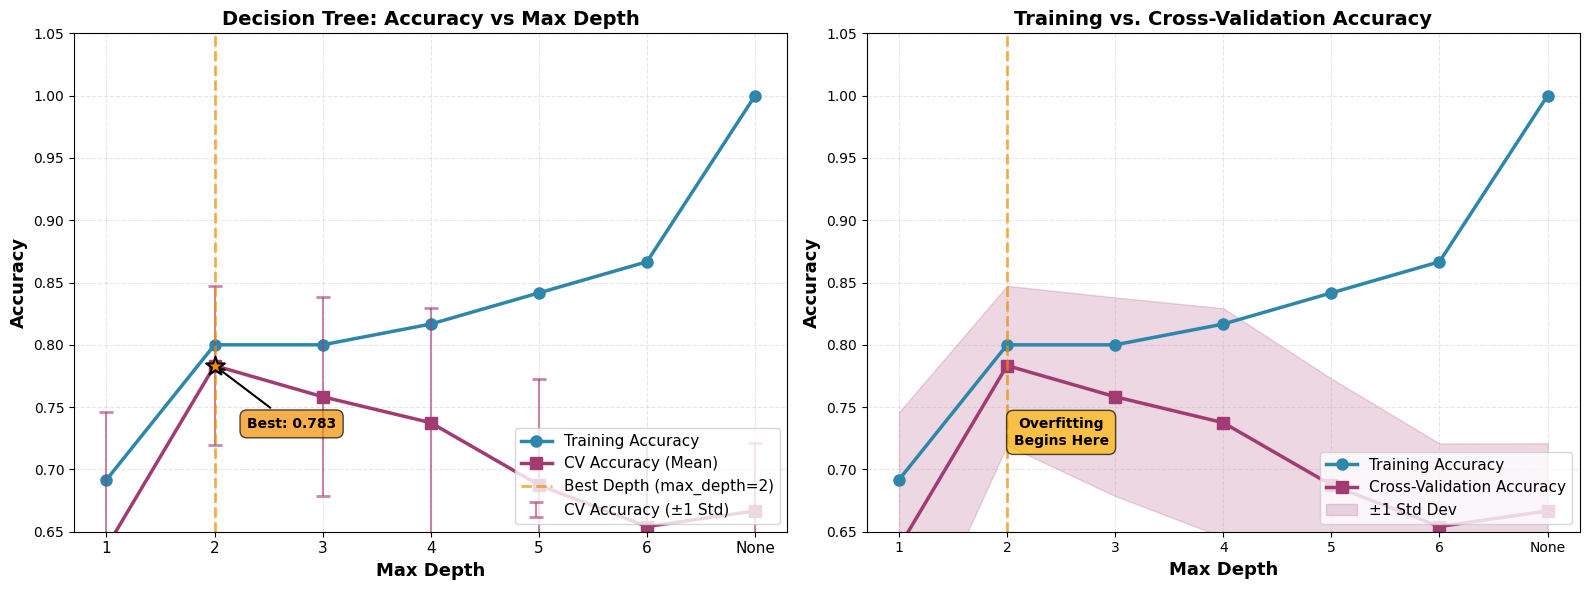


DECISION TREE OVERFITTING ANALYSIS SUMMARY
Max Depth    Training Acc     CV Acc (mean)      CV Std      
----------------------------------------------------------------------
1            0.6917           0.6375             0.1083      
2            0.8000           0.7833             0.0640       ← BEST
3            0.8000           0.7583             0.0797      
4            0.8167           0.7375             0.0919      
5            0.8417           0.6875             0.0854      
6            0.8667           0.6542             0.0667      
None         1.0000           0.6667             0.0543      

✓ Best max_depth: 2
✓ Best CV Accuracy: 0.7833
✓ Overfitting Indication:
  - Training Acc Gap at depth None: 0.3333


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ========== PLOT 1: Accuracy vs max_depth with labeled decision tree ==========
ax1 = axes[0]

# Plot both accuracies
x_pos = np.arange(len(depths))
ax1.plot(x_pos, train_accs, 'o-', label='Training Accuracy', linewidth=2.5, markersize=8, color='#2E86AB')
ax1.plot(x_pos, cv_means, 's-', label='CV Accuracy (Mean)', linewidth=2.5, markersize=8, color='#A23B72')

# Add error bars for CV accuracy
ax1.errorbar(x_pos, cv_means, yerr=cv_stds, fmt='none', capsize=5, capthick=2, 
             ecolor='#A23B72', alpha=0.6, label='CV Accuracy (±1 Std)')

# Highlight the best depth
best_x = x_pos[best_idx]
ax1.axvline(x=best_x, color='#F18F01', linestyle='--', linewidth=2, alpha=0.7, label=f'Best Depth (max_depth={best_depth})')
ax1.scatter([best_x], [cv_means[best_idx]], s=200, color='#F18F01', marker='*', zorder=5, edgecolors='black', linewidth=1.5)

# Configure x-axis with depth labels
ax1.set_xticks(x_pos)
ax1.set_xticklabels(depth_labels, fontsize=11)
ax1.set_xlabel('Max Depth', fontsize=13, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=13, fontweight='bold')
ax1.set_title('Decision Tree: Accuracy vs Max Depth', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=11)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_ylim([0.65, 1.05])

# Add annotation for best depth
ax1.annotate(f'Best: {cv_means[best_idx]:.3f}', 
             xy=(best_x, cv_means[best_idx]), 
             xytext=(best_x+0.3, cv_means[best_idx]-0.05),
             fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#F18F01', alpha=0.7),
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color='black', lw=1.5))

# ========== PLOT 2: Training vs Cross-Validation Accuracy ==========
ax2 = axes[1]

# Plot curves
ax2.plot(depth_labels, train_accs, 'o-', label='Training Accuracy', linewidth=2.5, markersize=8, color='#2E86AB')
ax2.plot(depth_labels, cv_means, 's-', label='Cross-Validation Accuracy', linewidth=2.5, markersize=8, color='#A23B72')

# Add shaded region for CV standard deviation
ax2.fill_between(range(len(depths)), 
                 [m - s for m, s in zip(cv_means, cv_stds)],
                 [m + s for m, s in zip(cv_means, cv_stds)],
                 alpha=0.2, color='#A23B72', label='±1 Std Dev')

# Highlight overfitting region (where gap increases)
ax2.axvline(x=best_idx, color='#F18F01', linestyle='--', linewidth=2, alpha=0.7)

ax2.set_xlabel('Max Depth', fontsize=13, fontweight='bold')
ax2.set_ylabel('Accuracy', fontsize=13, fontweight='bold')
ax2.set_title('Training vs. Cross-Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right', fontsize=11)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_ylim([0.65, 1.05])

# Add overfitting annotation
ax2.text(best_idx + 0.5, 0.72, 'Overfitting\nBegins Here', fontsize=10, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFB703', alpha=0.7),
         ha='center')

plt.tight_layout()
plt.show()

# ========== Summary Table ==========
print("\n" + "="*70)
print("DECISION TREE OVERFITTING ANALYSIS SUMMARY")
print("="*70)
print(f"{'Max Depth':<12} {'Training Acc':<16} {'CV Acc (mean)':<18} {'CV Std':<12}")
print("-"*70)
for depth_label, train_acc, cv_mean, cv_std in zip(depth_labels, train_accs, cv_means, cv_stds):
    marker = " ← BEST" if cv_mean == cv_means[best_idx] else ""
    print(f"{depth_label:<12} {train_acc:<16.4f} {cv_mean:<18.4f} {cv_std:<12.4f}{marker}")
print("="*70)
print(f"\n✓ Best max_depth: {best_depth}")
print(f"✓ Best CV Accuracy: {cv_means[best_idx]:.4f}")
print(f"✓ Overfitting Indication:")
print(f"  - Training Acc Gap at depth {depth_labels[-1]}: {train_accs[-1] - cv_means[-1]:.4f}")